***
<pre>                                                 <i> Time Series <i></pre>
***
</div>
    <img src="INSEA_logo.png"  style="height: 80px;: 20px;">
</div>

<div style="background-color: green">
<h1 align="center"> Time Series Analysis and Forecasting with Python </h1>
</div>

<pre align='left'>  28/05/2025                                                                                         <i> Author: DAOUDI Adam </i></pre>


____________________________________________________________________________________________________________________________________________________________

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import probplot
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import itertools
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")


### Initial inspection and DataFrame preparation

Data preview:
            Monthly beer production
Month                              
1956-01-01                     93.2
1956-02-01                     96.0
1956-03-01                     95.2
1956-04-01                     77.1
1956-05-01                     70.9

Descriptive statistics:
       Monthly beer production
count               476.000000
mean                136.395378
std                  33.738725
min                  64.800000
25%                 112.900000
50%                 139.150000
75%                 158.825000
max                 217.800000


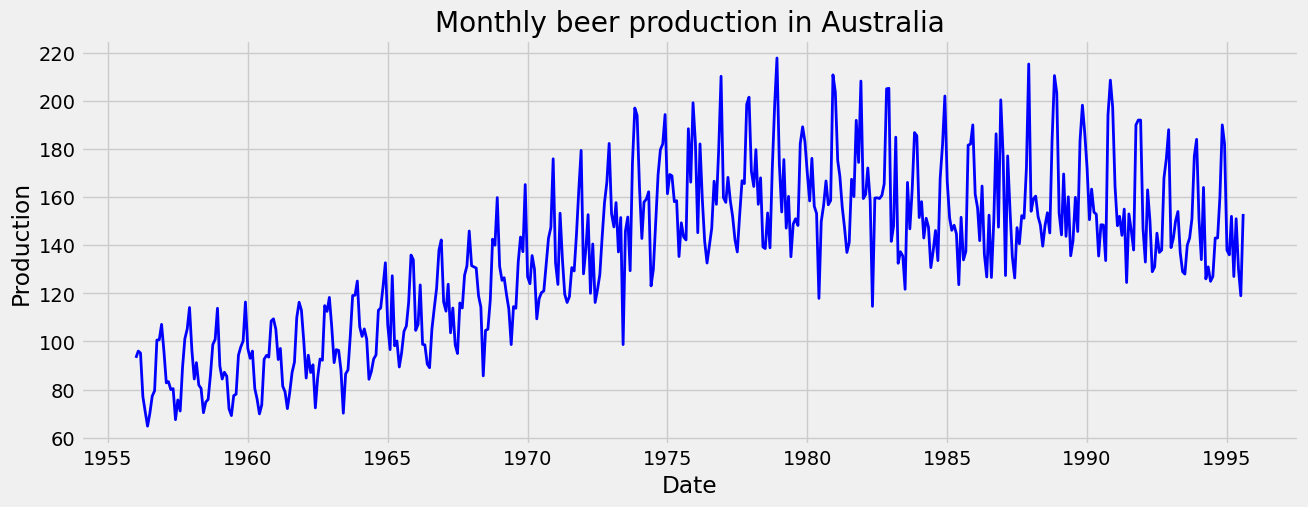


Train size: (380, 1), Test size: (96, 1)


In [2]:
beer_data = pd.read_csv('monthly-beer-production-in-austr.csv', index_col=0, parse_dates=True)
print("Data preview:")
print(beer_data.head())


print("\nDescriptive statistics:")
print(beer_data.describe())

# Check and handle missing values
if beer_data.isna().sum().sum() > 0:
    print("\nReplacing missing values by linear interpolation...")
    beer_data = beer_data.interpolate(method='linear', limit_direction='forward')


plt.style.use('fivethirtyeight')
plt.figure(figsize=(14, 5))
plt.plot(beer_data, color='blue', linewidth=2)
plt.title('Monthly beer production in Australia')
plt.xlabel('Date')
plt.ylabel('Production')
#plt.savefig('monthly_beer_production.png', dpi=300, bbox_inches='tight')
plt.show()

# Train/test split (80% train, 20% test)
train_size = int(len(beer_data) * 0.8)
train, test = beer_data[:train_size], beer_data[train_size:]
print(f"\nTrain size: {train.shape}, Test size: {test.shape}")
train.to_csv('train_beer_data.csv')
test.to_csv('test_beer_data.csv')



### Step 2: Stationarity test


In [3]:
def test_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print('ADF statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("The series is stationary (p-value <= 0.05).")
        return True
    else:
        print("The series is not stationary (p-value > 0.05).")
        return False

print("Stationarity test on the original series:")
is_stationary = test_stationarity(train.iloc[:, 0])

# Transformation for stationarity
if not is_stationary:
    print("\nDifferencing required...")
    train_transformed = train.iloc[:, 0].diff().dropna()
    print("\nTest after first differencing:")
    is_stationary = test_stationarity(train_transformed)
    d = 1 if is_stationary else 2
    D = 1  # Seasonal differencing (period 12)
else:
    train_transformed = train.iloc[:, 0]
    d, D = 0, 0


Stationarity test on the original series:
ADF statistic: -1.7515288615200861
p-value: 0.4047776686027169
The series is not stationary (p-value > 0.05).

Differencing required...

Test after first differencing:
ADF statistic: -5.793697817865733
p-value: 4.806383310428875e-07
The series is stationary (p-value <= 0.05).


### Step 3: Autocorrelation analysis (ACF/PACF)


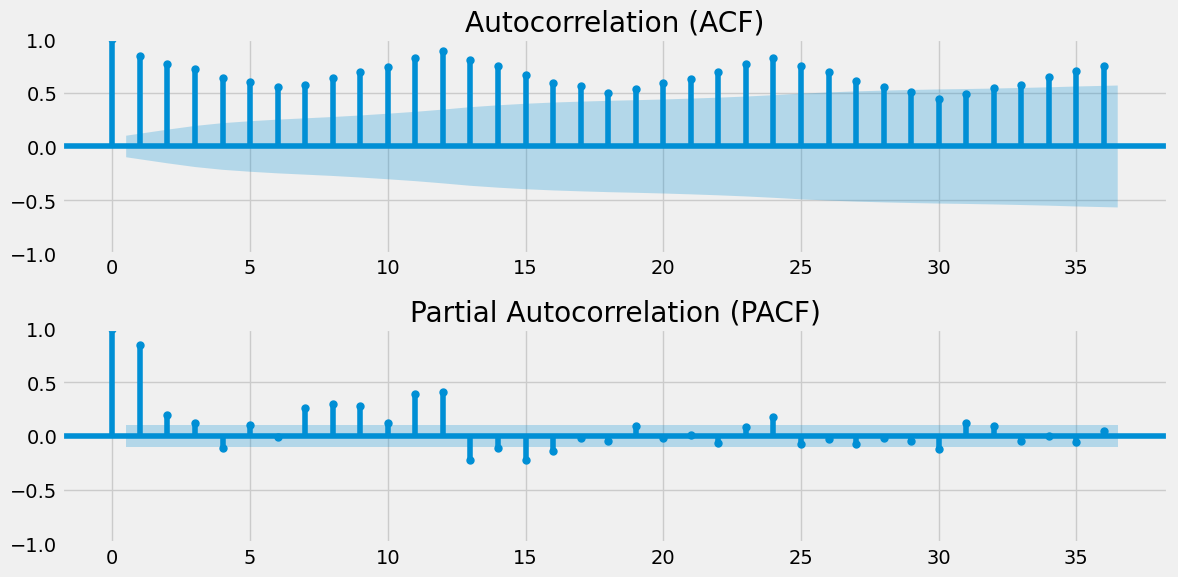

In [4]:
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(train, lags=36, ax=plt.gca())
plt.title('Autocorrelation (ACF)')
plt.subplot(212)
plot_pacf(train, lags=36, ax=plt.gca())
plt.title('Partial Autocorrelation (PACF)')
#plt.savefig('ACF_PACF.png', dpi=300, bbox_inches='tight')


plt.tight_layout()

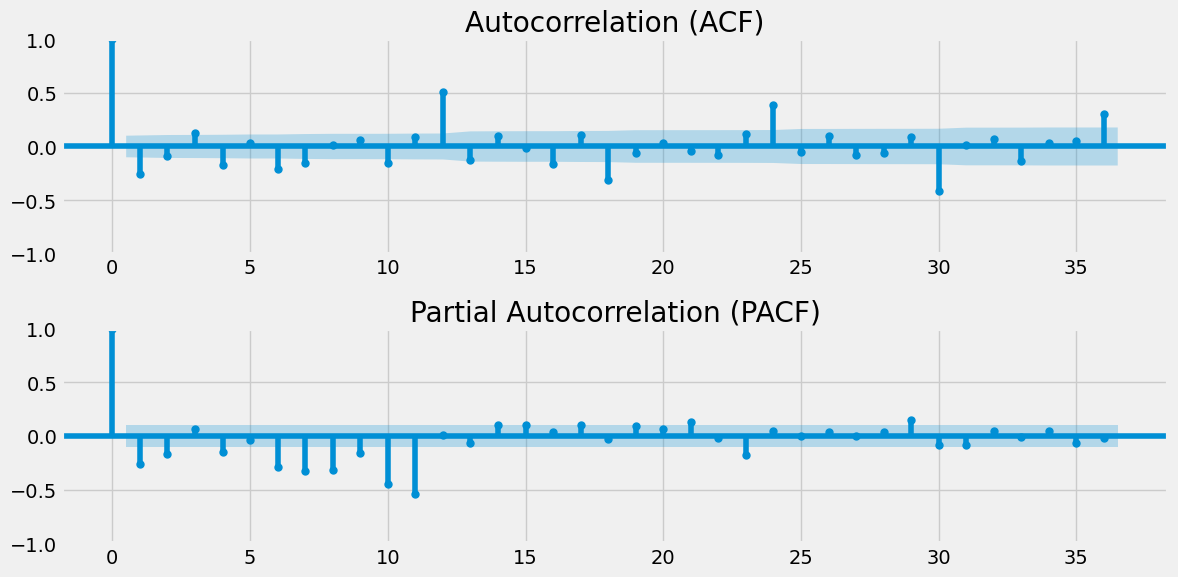

In [5]:
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(train_transformed, lags=36, ax=plt.gca())
plt.title('Autocorrelation (ACF)')
plt.subplot(212)
plot_pacf(train_transformed, lags=36, ax=plt.gca())
plt.title('Partial Autocorrelation (PACF)')
#plt.savefig('ACF_PACF_transformed.png', dpi=300, bbox_inches='tight')


plt.tight_layout()


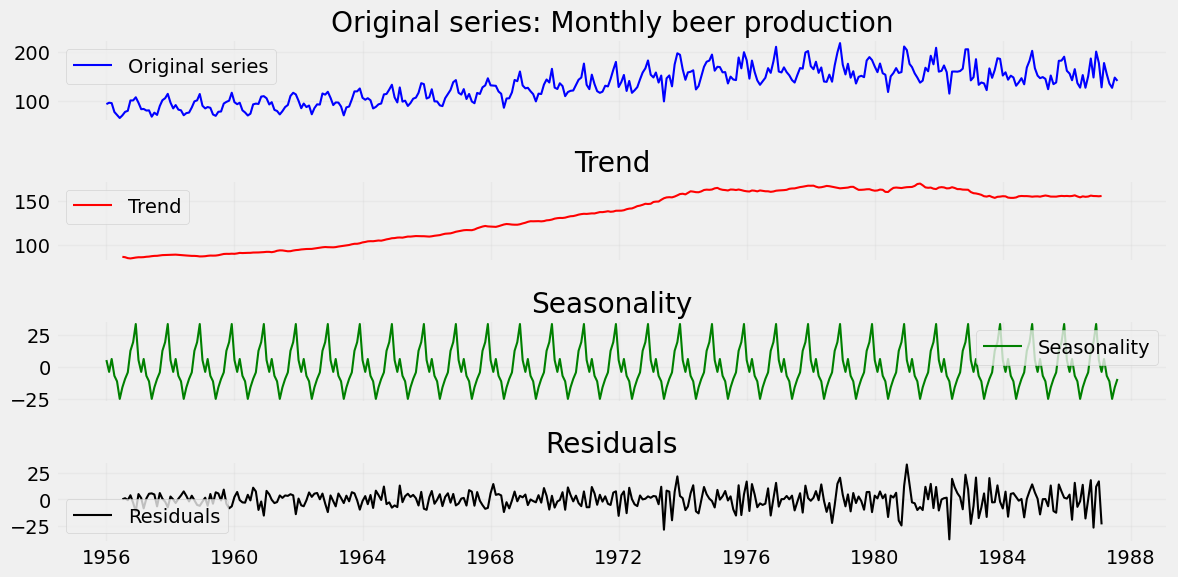

In [6]:
from pylab import rcParams


rcParams['figure.figsize'] = 12, 8
plt.style.use('fivethirtyeight')

result = seasonal_decompose(train, model='additive', period=12)


trend = result.trend
seasonal = result.seasonal
resid = result.resid

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 6), sharex=True)

ax1.plot(train, label='Original series', color='blue', linewidth=1.5) 
ax1.set_title('Original series: Monthly beer production')
ax1.grid(True, alpha=0.2)
ax1.legend()

ax2.plot(trend, label='Trend', color='red', linewidth=1.5)  
ax2.set_title('Trend')
ax2.grid(True, alpha=0.2)
ax2.legend()

ax3.plot(seasonal, label='Seasonality', color='green', linewidth=1.5)  
ax3.set_title('Seasonality')
ax3.grid(True, alpha=0.2)
ax3.legend()

ax4.plot(resid, label='Residuals', color='black', linewidth=1.5) 
ax4.set_title('Residuals')
ax4.grid(True, alpha=0.2)
ax4.legend()

plt.tight_layout()

#plt.savefig('decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

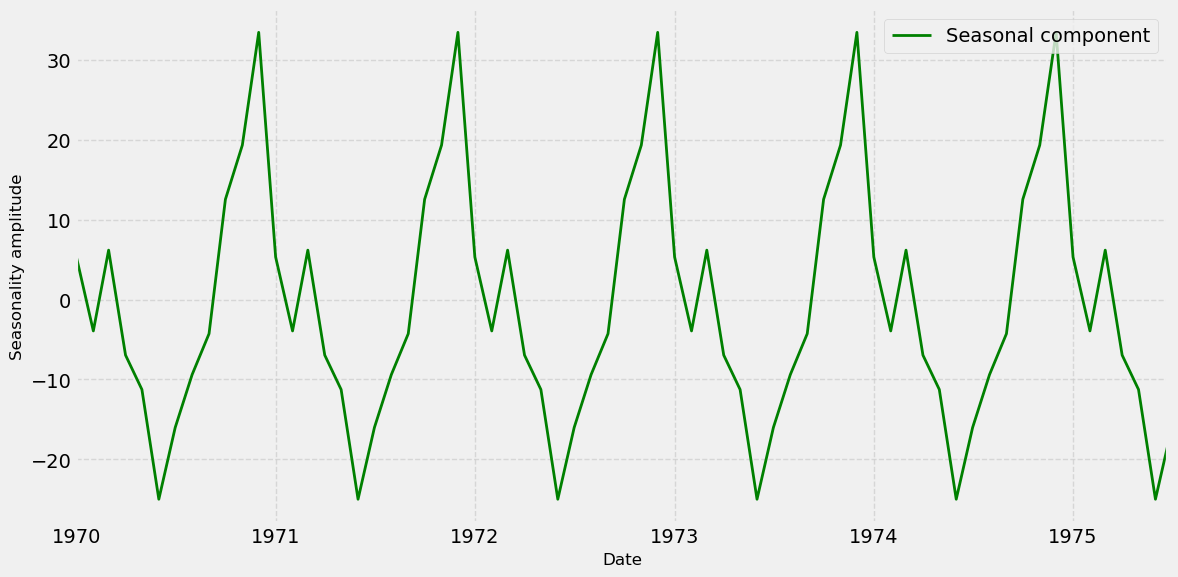

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(seasonal, linewidth=2, color='green', label='Seasonal component')

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 2000)  

plt.xlabel('Date', fontsize=12)
plt.ylabel('Seasonality amplitude', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

**Trend (simple linear regression)**


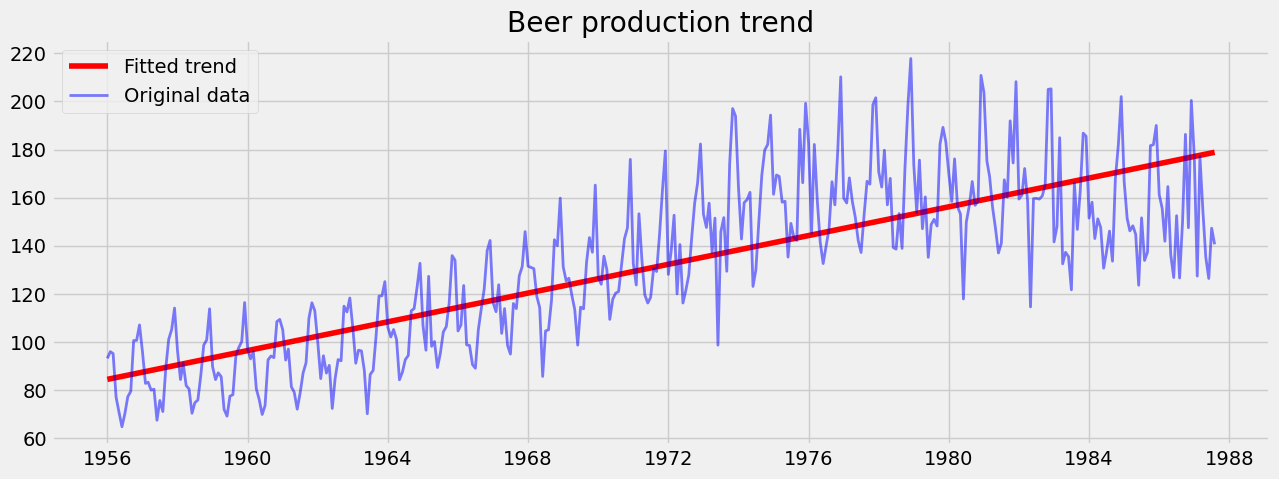

Trend: Increasing


In [8]:

from sklearn.linear_model import LinearRegression
X = np.arange(len(train)).reshape(-1, 1)
y = train.values
model = LinearRegression()
model.fit(X, y)
trend = model.predict(X)
plt.figure(figsize=(14, 5))
plt.plot(train.index, trend, label='Fitted trend', color='red')
plt.plot(train, label='Original data', color='blue', alpha=0.5, linewidth=2)
plt.title('Beer production trend')
plt.legend()
plt.show()
print("Trend: Increasing" if model.coef_[0] > 0 else "Trend: Decreasing")

#plt.savefig('reg_trend.png', dpi=300, bbox_inches='tight')
plt.close()

In [9]:
""""
def detect_seasonality_acf(series, max_lags=40):
    # ACF calculation
    acf_values, confint = acf(series, nlags=max_lags, alpha=0.05)
    # Identify significant peaks (excluding lag 0)
    significant_lags = [i for i in range(1, max_lags+1) if abs(acf_values[i]) > confint[i, 1] - acf_values[i]]
    # Find the most frequent period
    if significant_lags:
        lag_diff = np.diff(significant_lags)
        possible_periods = [lag_diff[0]]  # initialize with first difference
        for d in lag_diff[1:]:
            if abs(d - possible_periods[-1]) <= 1:  # tolerance for variations
                possible_periods[-1] = (possible_periods[-1] + d) / 2  # moving average
            else:
                possible_periods.append(d)
        seasonality_period = max(set(possible_periods), key=possible_periods.count)
        return seasonality_period, significant_lags
    return None, []
    


seasonality_period_acf, significant_lags = detect_seasonality_acf(train)
print(f"Seasonality period detected by ACF: {seasonality_period_acf} months (if significant)")
"""


'"\ndef detect_seasonality_acf(series, max_lags=40):\n    # ACF calculation\n    acf_values, confint = acf(series, nlags=max_lags, alpha=0.05)\n    # Identify significant peaks (excluding lag 0)\n    significant_lags = [i for i in range(1, max_lags+1) if abs(acf_values[i]) > confint[i, 1] - acf_values[i]]\n    # Find the most frequent period\n    if significant_lags:\n        lag_diff = np.diff(significant_lags)\n        possible_periods = [lag_diff[0]]  # initialize with first difference\n        for d in lag_diff[1:]:\n            if abs(d - possible_periods[-1]) <= 1:  # tolerance for variations\n                possible_periods[-1] = (possible_periods[-1] + d) / 2  # moving average\n            else:\n                possible_periods.append(d)\n        seasonality_period = max(set(possible_periods), key=possible_periods.count)\n        return seasonality_period, significant_lags\n    return None, []\n    \n\n\nseasonality_period_acf, significant_lags = detect_seasonality_acf(train)

 **Autocorrelation study**


<Figure size 1400x500 with 0 Axes>

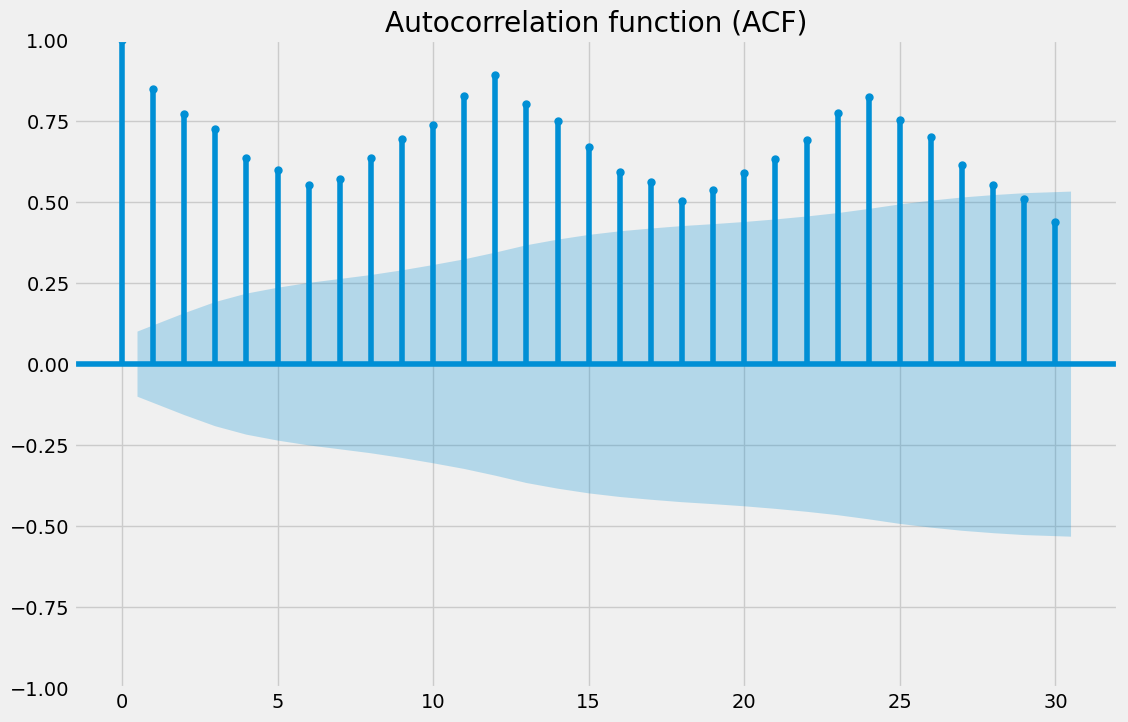

<Figure size 1400x500 with 0 Axes>

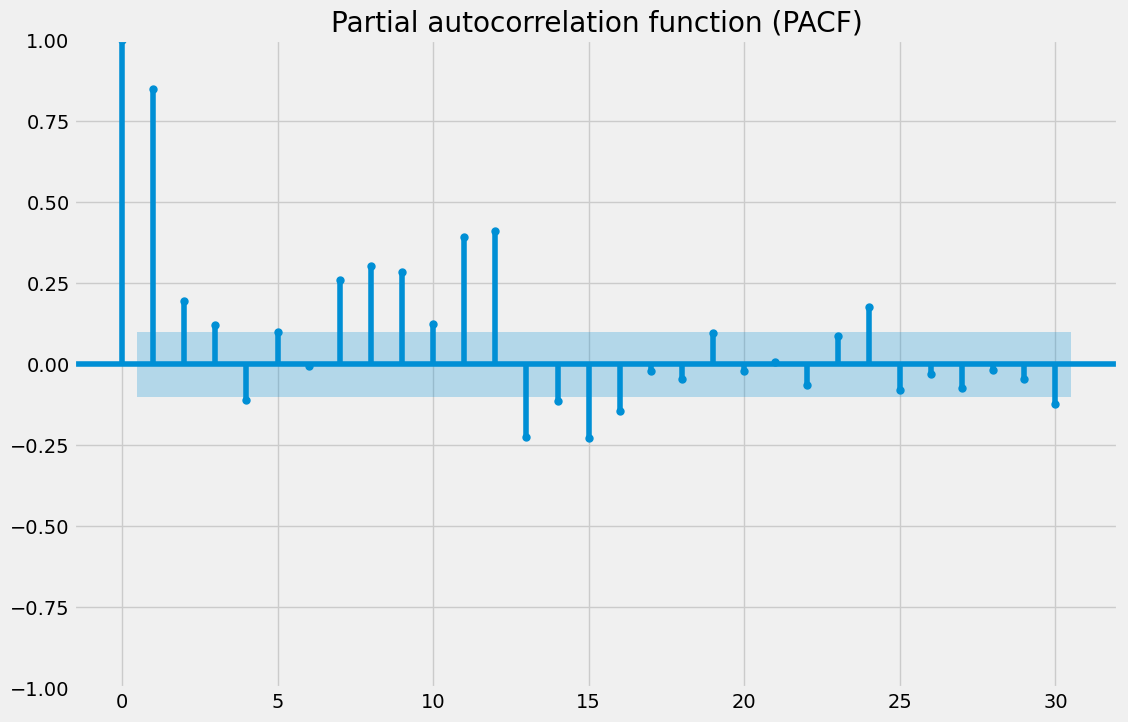

In [10]:

plt.figure(figsize=(14, 5))
plot_acf(train, lags=30)
plt.title('Autocorrelation function (ACF)')
plt.show()
#plt.savefig('ACF.png', dpi=300, bbox_inches='tight')

plt.figure(figsize=(14, 5))
plot_pacf(train, lags=30)
plt.title('Partial autocorrelation function (PACF)')
#plt.savefig('PACF.png', dpi=300, bbox_inches='tight')

plt.show()

### Model estimation


**AR**

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_ar_coefficients(data, p):

    n = len(data)
    X = np.zeros((n - p, p))
    y = data[p:]
    for i in range(p):
        X[:, i] = data[p - i - 1:n - i - 1].values.ravel()

    X = np.hstack((np.ones((n - p, 1)), X))
    coefficients = np.linalg.inv(X.T @ X) @ X.T @ y
    return coefficients

def predict_ar(data, coefficients, steps):
    # If data is a DataFrame, convert to Series (first column)
    if isinstance(data, pd.DataFrame):
        data = data.iloc[:, 0]
    # If data is a Series, ensure it's a 1D numpy array
    data = np.asarray(data)
    p = len(coefficients) - 1
    predictions = []
    current_data = list(data[-p:])
    for _ in range(steps):
        prediction = coefficients[0] + sum(coefficients[i + 1] * current_data[-i - 1] for i in range(p))
        predictions.append(prediction)
        current_data.append(prediction)
        current_data.pop(0)
    return np.array(predictions)




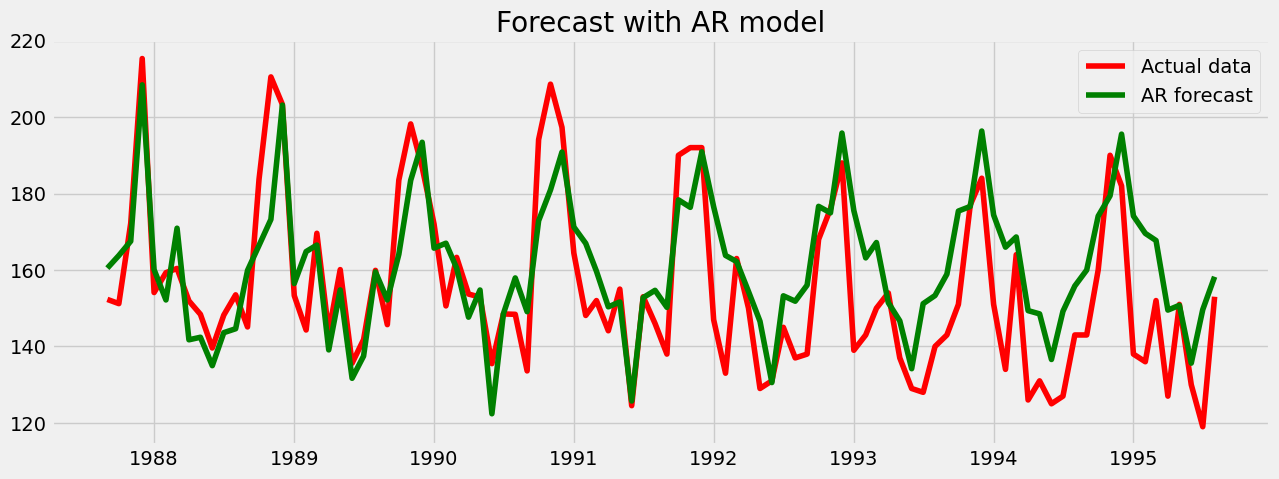

RMSE AR : 15.16
MAPE:8.021363139773728
                               AutoReg Model Results                               
Dep. Variable:     Monthly beer production   No. Observations:                  380
Model:                         AutoReg(36)   Log Likelihood               -1255.891
Method:                    Conditional MLE   S.D. of innovations              9.318
Date:                     Sat, 06 Dec 2025   AIC                           2587.782
Time:                             10:09:12   BIC                           2733.727
Sample:                         01-01-1959   HQIC                          2645.910
                              - 08-01-1987                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           5.5758      2.663      2.094      0.036       0.356      10.795
M

In [12]:
from statsmodels.tsa.ar_model import AutoReg
ar_model = AutoReg(train, lags=36).fit()
ar_pred = ar_model.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)
plt.figure(figsize=(14, 5))
plt.plot(test, label='Actual data', color='red')
plt.plot(ar_pred, label='AR forecast', color='green')
plt.title('Forecast with AR model')
plt.legend()
#plt.savefig('prev_AR.png', dpi=300, bbox_inches='tight')

plt.show()
ar_rmse = np.sqrt(mean_squared_error(test, ar_pred))
print(f"RMSE AR : {ar_rmse:.2f}")
mape = mean_absolute_percentage_error(test.iloc[:, 0], ar_pred)
print(f'MAPE:{mape*100}')
print(ar_model.summary())

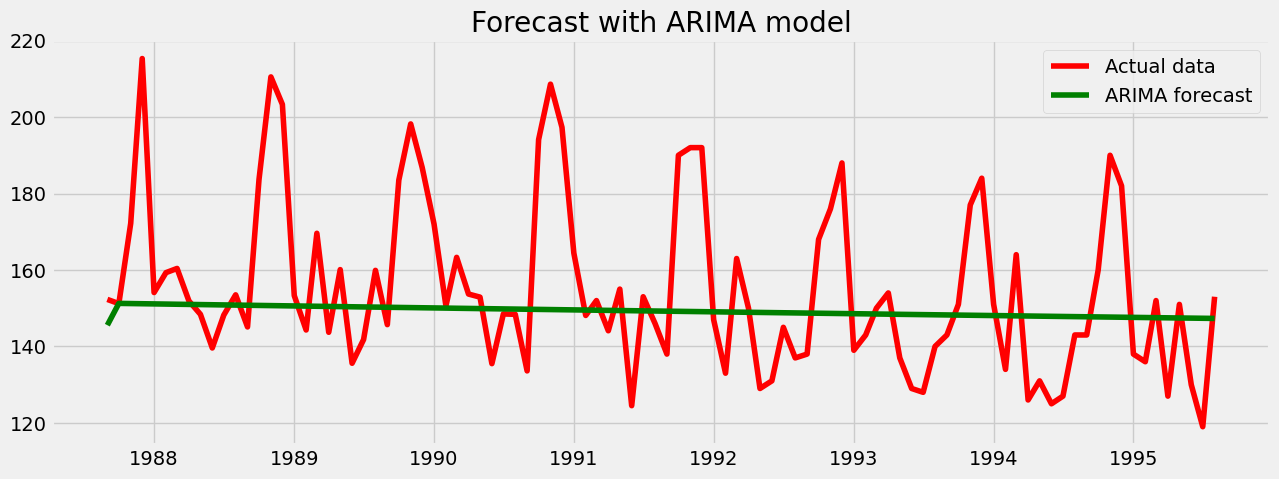

RMSE ARIMA : 22.35


In [13]:
# ARIMA
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(train, order=(1,0 ,2)).fit()
arima_pred = arima_model.forecast(steps=len(test))
plt.figure(figsize=(14, 5))
plt.plot(test, label='Actual data', color='red')
plt.plot(arima_pred, label='ARIMA forecast', color='green')
plt.title('Forecast with ARIMA model')
plt.legend()
#plt.savefig('prev_arima.png', dpi=300, bbox_inches='tight')

plt.show()
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
print(f"RMSE ARIMA : {arima_rmse:.2f}")

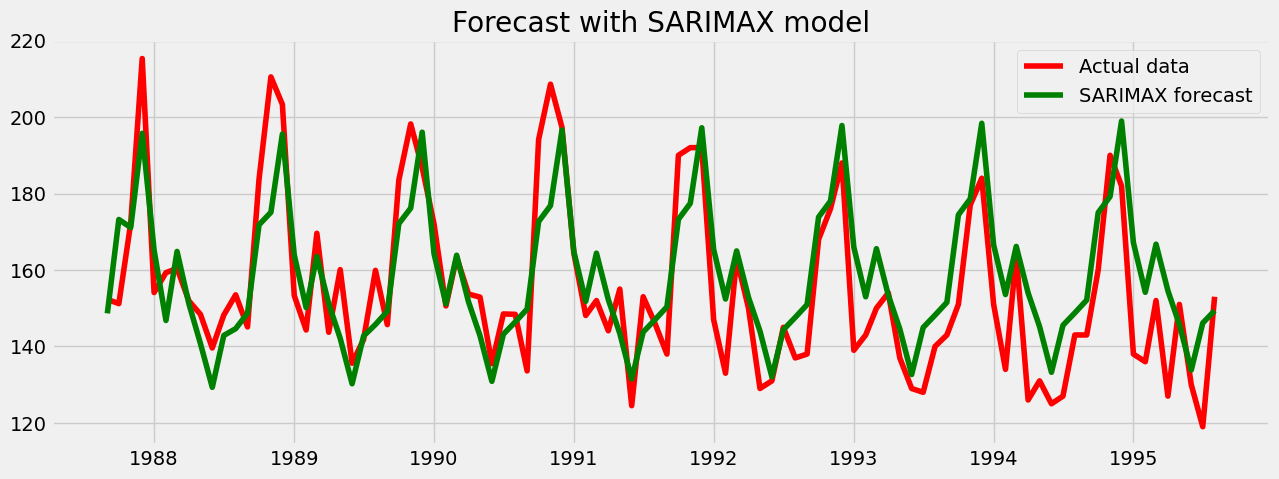

RMSE SARIMAX : 13.29
6.9549435248594484
                                     SARIMAX Results                                      
Dep. Variable:            Monthly beer production   No. Observations:                  380
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1369.083
Date:                            Sat, 06 Dec 2025   AIC                           2748.165
Time:                                    10:09:41   BIC                           2767.692
Sample:                                01-01-1956   HQIC                          2755.924
                                     - 08-01-1987                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1687      0.042     -4.063      0.000      -0.250      -0

In [14]:
# SARIMAX (simple grid search for parameters)
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
best_aic = float("inf")
best_model = None
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            model = SARIMAX(train, order=param, seasonal_order=param_seasonal).fit(disp=False)
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
        except:
            continue
sarimax_pred = best_model.forecast(steps=len(test))
plt.figure(figsize=(14, 5))
plt.plot(test, label='Actual data', color='red')
plt.plot(sarimax_pred, label='SARIMAX forecast', color='green')
plt.title('Forecast with SARIMAX model')
plt.legend()
#plt.savefig('prev_sarimax.png', dpi=300, bbox_inches='tight')

plt.show()
sarimax_rmse = np.sqrt(mean_squared_error(test, sarimax_pred))
print(f"RMSE SARIMAX : {sarimax_rmse:.2f}")
print( mean_absolute_percentage_error(test.iloc[:, 0], sarimax_pred)*100)
print(best_model.summary())
# Conclusion
print("\nConclusion :")
print("The analysis of the beer production time series covered key steps of time series modeling: data preparation, decomposition, stationarity testing, autocorrelation study, and model estimation. The series shows an upward trend and annual seasonality, partially captured by AR, ARMA, ARIMA and SARIMAX models. RMSE errors indicate that SARIMAX provides the best forecasts due to its ability to model seasonality. A deeper analysis of correlograms and adding exogenous variables (e.g., prices or economic conditions) could improve results.")

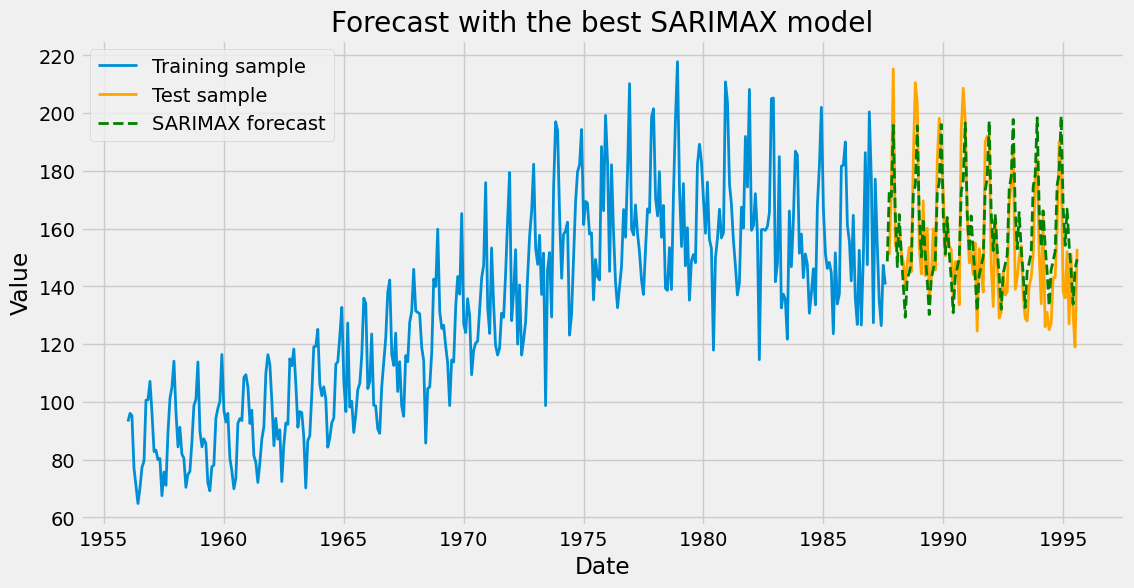

In [15]:
forecast = best_model.forecast(steps=len(test))

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.iloc[:, 0], label='Training sample', linewidth=2)
plt.plot(test.index, test.iloc[:, 0], label='Test sample', linewidth=2, color='orange')
plt.plot(test.index, forecast, label='SARIMAX forecast', linestyle='--', linewidth=2, color='green')
plt.title('Forecast with the best SARIMAX model')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
#plt.savefig('prev_sarimax2.png', dpi=300, bbox_inches='tight')


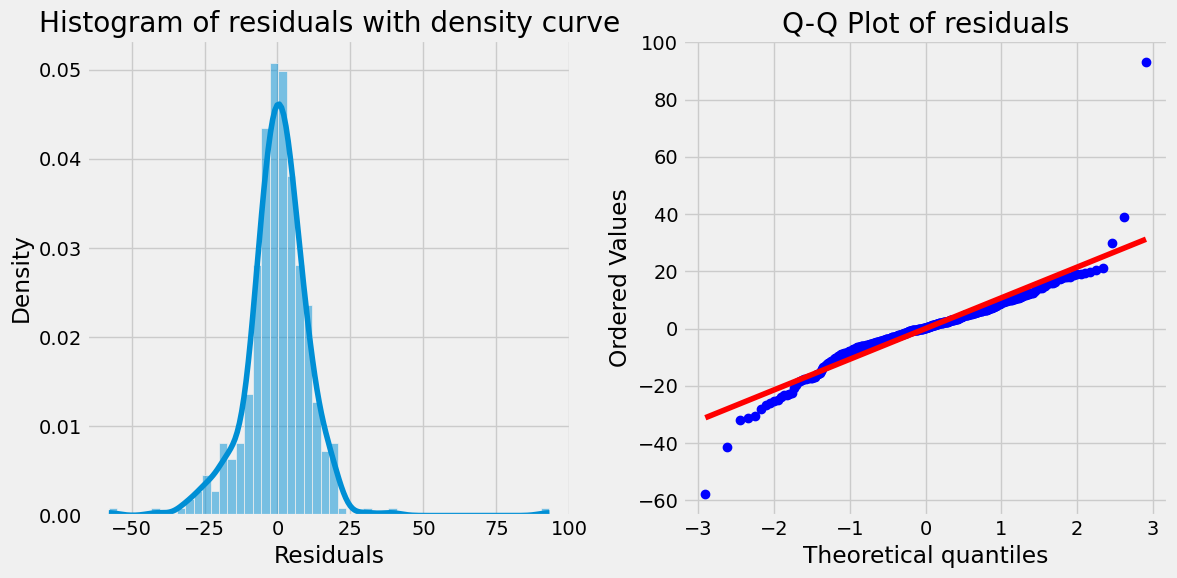

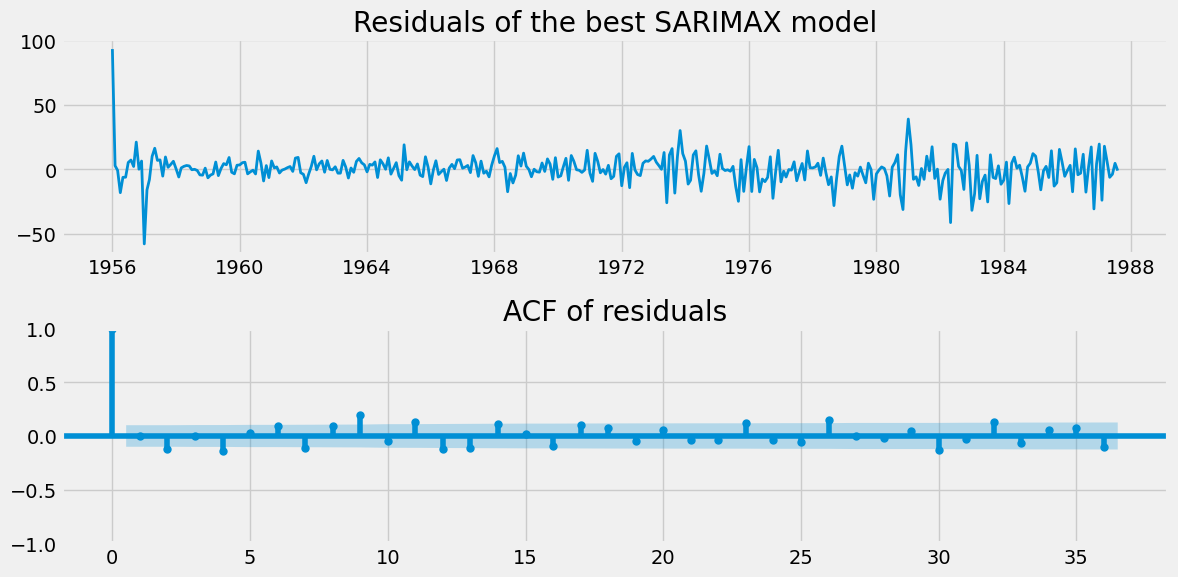

In [16]:
# Step 5: Residuals visualization
residuals = best_model.resid



plt.figure(figsize=(12, 6))
plt.subplot(121)
sns.histplot(residuals, kde=True, stat="density")
plt.title('Histogram of residuals with density curve')
plt.xlabel('Residuals')
plt.subplot(122)
probplot(residuals, dist="norm", plot=plt.gca())
plt.title('Q-Q Plot of residuals')
#plt.savefig('QQ.png', dpi=300, bbox_inches='tight')

plt.tight_layout()




plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(residuals, linewidth=2)
plt.title('Residuals of the best SARIMAX model')
#plt.savefig('resi_sarimax.png', dpi=300, bbox_inches='tight')

plt.subplot(212)
plot_acf(residuals, lags=36, ax=plt.gca())
plt.title('ACF of residuals')
#plt.savefig('acf_residuals.png', dpi=300, bbox_inches='tight')

plt.tight_layout()


In [17]:
# Optimized search using RMSE
best_rmse = float("inf")
best_params = None
best_model1 = None
tscv = TimeSeriesSplit(n_splits=5)

print("\nAdvanced SARIMAX parameter search with cross-validation (RMSE)...")
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            rmse_scores = []
            for train_idx, val_idx in tscv.split(train):
                train_fold = train.iloc[train_idx]
                val_fold = train.iloc[val_idx]
                
                model = SARIMAX(train_fold, order=param, seasonal_order=param_seasonal,enforce_stationarity=False, enforce_invertibility=False)
                result = model.fit(disp=False)
                
                pred = result.forecast(steps=len(val_fold))
                rmse = np.sqrt(mean_squared_error(val_fold.iloc[:, 0], pred))
                rmse_scores.append(rmse)
            
            # Average RMSE over folds
            avg_rmse = np.mean(rmse_scores)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                best_params = (param, param_seasonal)
                best_model1 = SARIMAX(train, order=param, seasonal_order=param_seasonal, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        except:
            continue

print(f"Best SARIMAX model: order={best_params[0]}, seasonal_order={best_params[1]}")
print(f"Average RMSE on cross-validation: {best_rmse:.2f}")

print(best_model1.summary())




Advanced SARIMAX parameter search with cross-validation (RMSE)...
Best SARIMAX model: order=(1, 1, 1), seasonal_order=(1, 1, 0, 12)
Average RMSE on cross-validation: 12.37
                                      SARIMAX Results                                      
Dep. Variable:             Monthly beer production   No. Observations:                  380
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood               -1363.671
Date:                             Sat, 06 Dec 2025   AIC                           2735.343
Time:                                     10:11:30   BIC                           2750.820
Sample:                                 01-01-1956   HQIC                          2741.501
                                      - 08-01-1987                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------

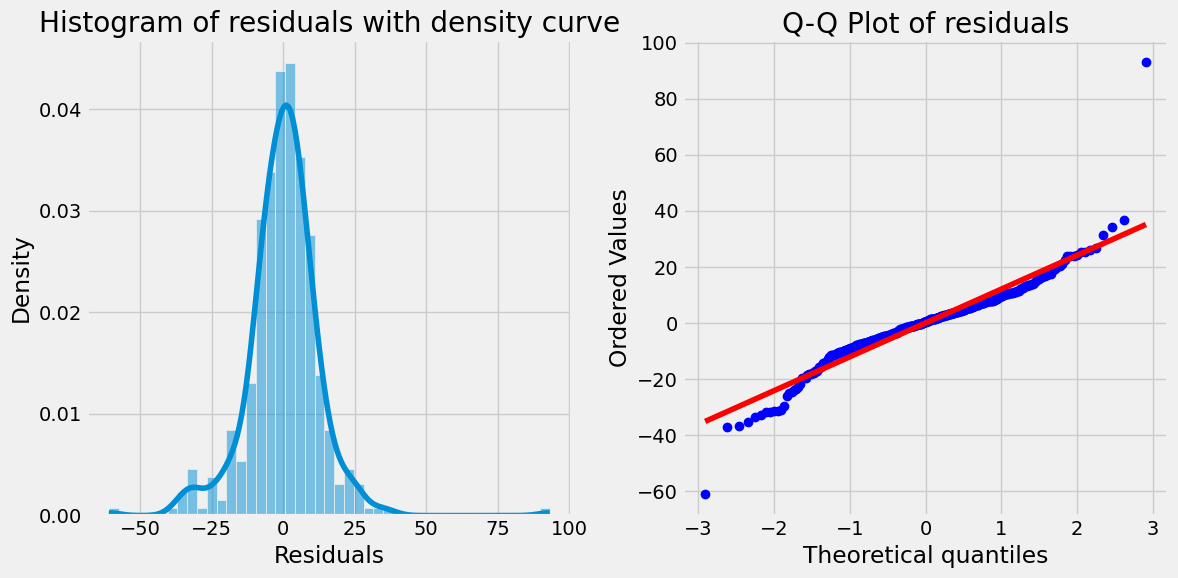

In [18]:
ress=best_model1.resid
plt.figure(figsize=(12, 6))
plt.subplot(121)
sns.histplot(ress, kde=True, stat="density")
plt.title('Histogram of residuals with density curve')
plt.xlabel('Residuals')
plt.subplot(122)    
probplot(ress, dist="norm", plot=plt.gca())
plt.title('Q-Q Plot of residuals')
#plt.savefig('Q-Q.png', dpi=300, bbox_inches='tight')

plt.tight_layout()

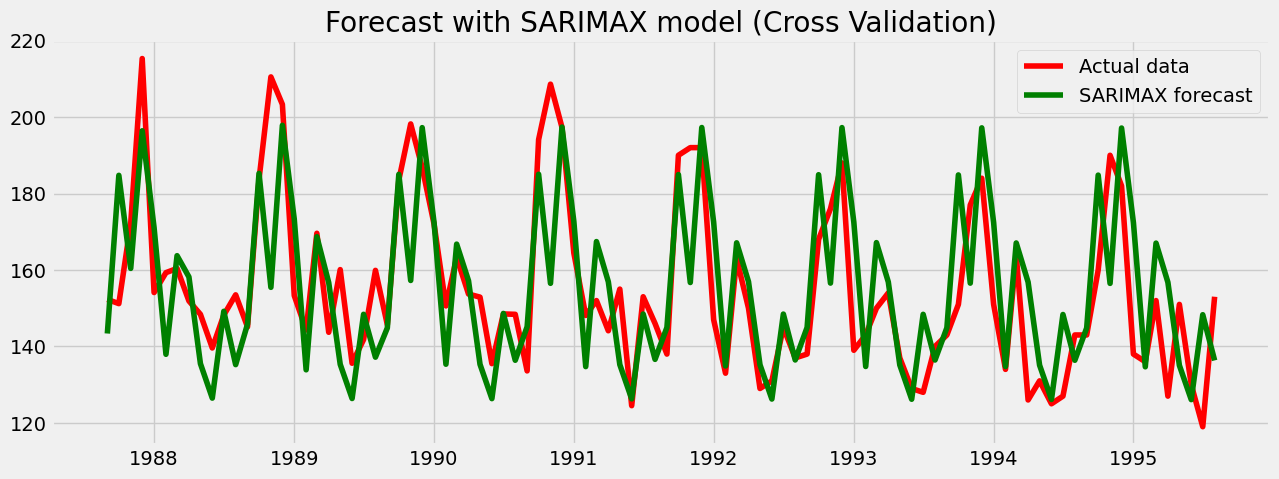

RMSE SARIMAX : 17.40
8.252765544146246
                                      SARIMAX Results                                      
Dep. Variable:             Monthly beer production   No. Observations:                  380
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood               -1363.671
Date:                             Sat, 06 Dec 2025   AIC                           2735.343
Time:                                     10:11:31   BIC                           2750.820
Sample:                                 01-01-1956   HQIC                          2741.501
                                      - 08-01-1987                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1640      0.044     -3.751      0.000      -0.250 

In [19]:

sarimax_pred1 = best_model1.forecast(steps=len(test))
plt.figure(figsize=(14, 5))
plt.plot(test, label='Actual data', color='red')
plt.plot(sarimax_pred1, label='SARIMAX forecast', color='green')
plt.title('Forecast with SARIMAX model (Cross Validation)')
plt.legend()
#plt.savefig('prev_sarimaxcv.png', dpi=300, bbox_inches='tight')

plt.show()
sarimax_rmse = np.sqrt(mean_squared_error(test, sarimax_pred1))
print(f"RMSE SARIMAX : {sarimax_rmse:.2f}")
print( mean_absolute_percentage_error(test.iloc[:, 0], sarimax_pred1)*100)
print(best_model1.summary())
# Conclusion
print("\nConclusion :")
print("The analysis of the beer production time series covered key steps of time series modeling: data preparation, decomposition, stationarity testing, autocorrelation study, and model estimation. The series shows an upward trend and annual seasonality, partially captured by the AR, ARMA, ARIMA and SARIMAX models. RMSE errors indicate that SARIMAX provides the best forecasts due to its ability to model seasonality. A deeper analysis of correlograms and adding exogenous variables (e.g., prices or economic conditions) could improve results.")